<a href="https://colab.research.google.com/github/Sonamgitdata/IIT-MAndi-Deep-learning/blob/main/Assignment1_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision matplotlib numpy

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.42MB/s]



Training images: 60000
Testing images : 10000

First 20 values of shuffle pattern:
[598 590 209 637 174 213 429 259 593 204 576 244 235 218 770 155 516  67
 579 109]

TRAINING FCNN ON NORMAL MNIST
Epoch [1/10] Loss: 0.2646 Accuracy: 92.15%
Epoch [2/10] Loss: 0.1112 Accuracy: 96.61%
Epoch [3/10] Loss: 0.0775 Accuracy: 97.54%
Epoch [4/10] Loss: 0.0615 Accuracy: 98.07%
Epoch [5/10] Loss: 0.0487 Accuracy: 98.41%
Epoch [6/10] Loss: 0.0399 Accuracy: 98.68%
Epoch [7/10] Loss: 0.0324 Accuracy: 98.94%
Epoch [8/10] Loss: 0.0287 Accuracy: 99.05%
Epoch [9/10] Loss: 0.0265 Accuracy: 99.11%
Epoch [10/10] Loss: 0.0242 Accuracy: 99.19%

Normal MNIST Test Accuracy: 97.69%

TRAINING FCNN ON SCRAMBLED MNIST
Epoch [1/10] Loss: 0.2730 Accuracy: 91.81%
Epoch [2/10] Loss: 0.1164 Accuracy: 96.44%
Epoch [3/10] Loss: 0.0801 Accuracy: 97.53%
Epoch [4/10] Loss: 0.0643 Accuracy: 97.94%
Epoch [5/10] Loss: 0.0488 Accuracy: 98.44%
Epoch [6/10] Loss: 0.0420 Accuracy: 98.60%
Epoch [7/10] Loss: 0.0348 Accuracy: 98.82%


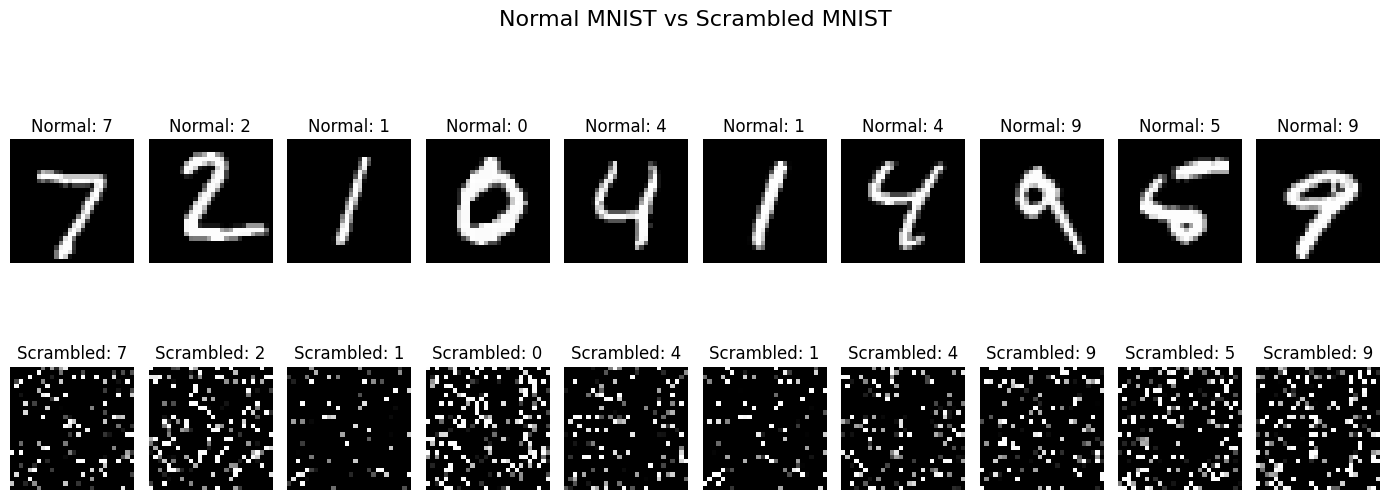

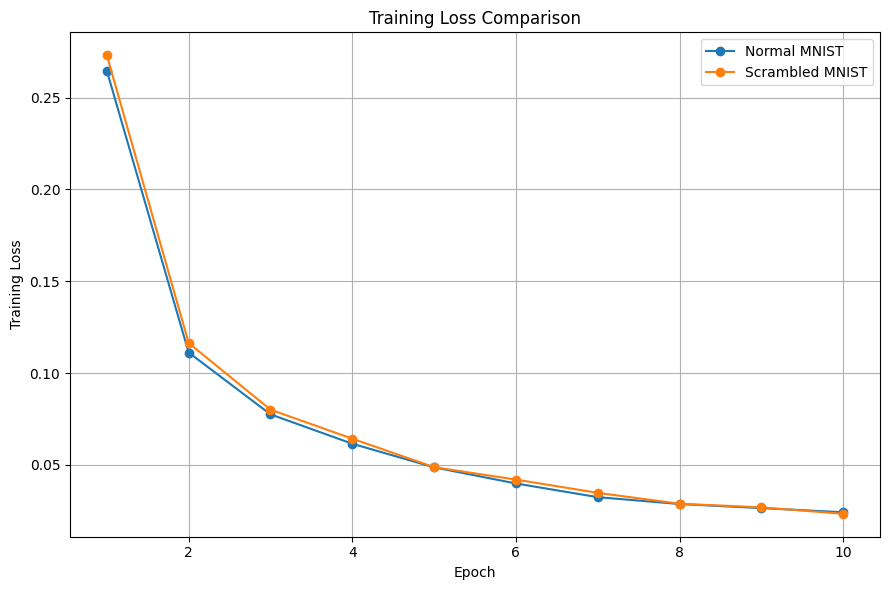

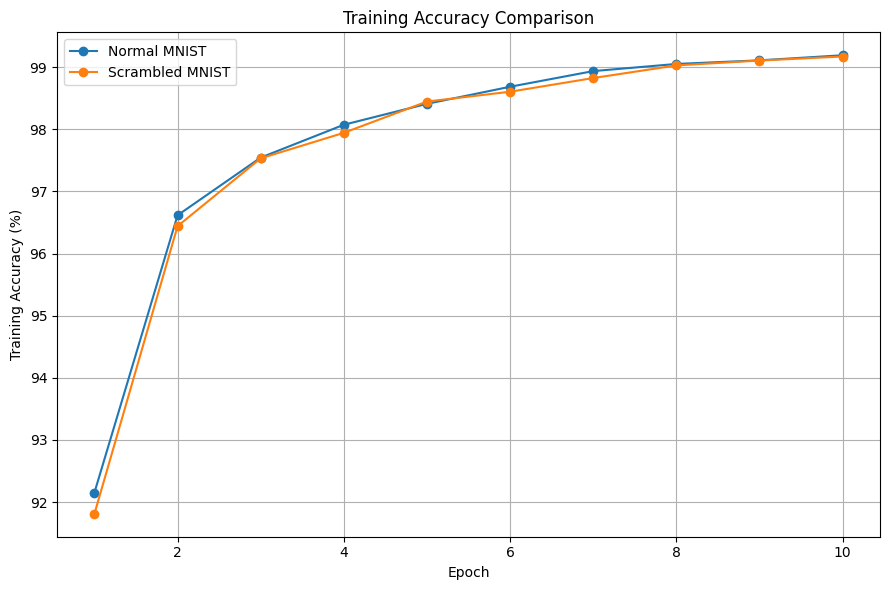

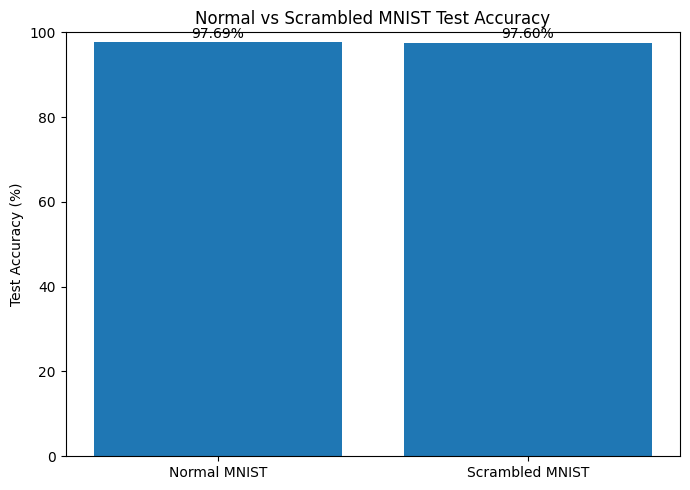


Normal latent shape: (5000, 64)
Scrambled latent shape: (5000, 64)


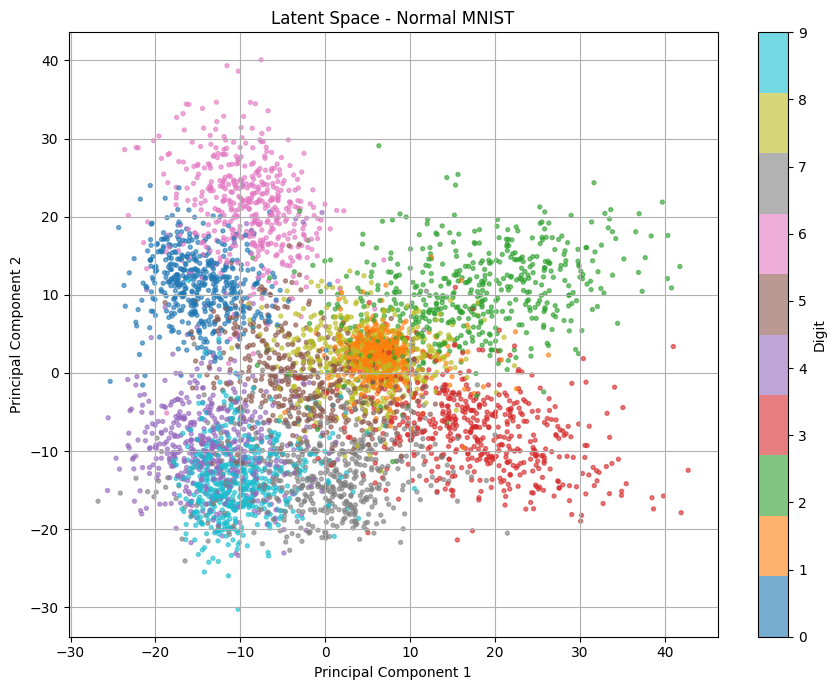

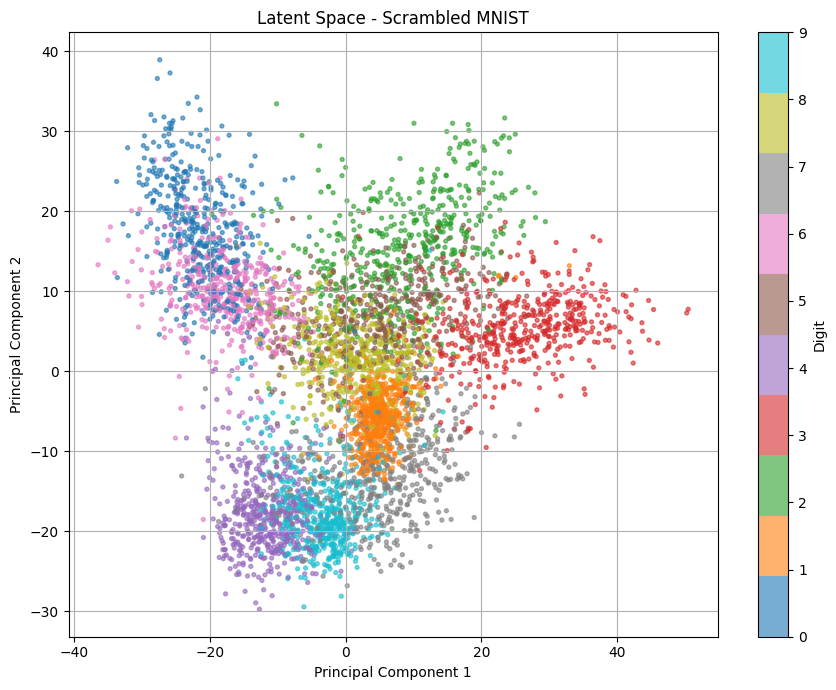


EXPERIMENT COMPLETED
Normal MNIST Accuracy    : 97.69%
Scrambled MNIST Accuracy : 97.60%
Accuracy Difference      : 0.09%

Files generated:
------------------------------
normal_vs_scrambled.png
loss_comparison.png
accuracy_comparison_training.png
test_accuracy_comparison.png
latent_space_normal.png
latent_space_scrambled.png
normal_mnist_fcnn.pth
scrambled_mnist_fcnn.pth


In [2]:
"""
===============================================================
PART 2 - QUESTION 2.2
THE "FLATTENING" / SCRAMBLED MNIST EXPERIMENT
===============================================================

Objective:
---------
1. Load MNIST dataset.
2. Train an FCNN on normal MNIST.
3. Randomly shuffle the pixels of every image.
4. IMPORTANT: Use the SAME shuffle pattern for every image.
5. Train the same FCNN on scrambled MNIST.
6. Compare test accuracy.
7. Visualize normal and scrambled images.
8. Analyze latent-space representations using PCA.

Main Concept:
-------------
An FCNN does not have built-in spatial awareness.

A human recognizes:
    lines + curves + spatial arrangement -> digit

An FCNN mainly sees:
    784 numerical input features -> digit

Therefore, an FCNN can sometimes perform similarly
on consistently scrambled MNIST.
===============================================================
"""


# ===============================================================
# 1. IMPORT LIBRARIES
# ===============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt


# ===============================================================
# 2. SET RANDOM SEEDS
# ===============================================================

"""
Using a fixed seed makes the experiment reproducible.
"""

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)


# ===============================================================
# 3. CONFIGURATION
# ===============================================================

BATCH_SIZE = 64

LEARNING_RATE = 0.001

EPOCHS = 10

INPUT_SIZE = 28 * 28       # 784

HIDDEN_SIZE_1 = 128

HIDDEN_SIZE_2 = 64

OUTPUT_SIZE = 10


# Select GPU if available.
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", DEVICE)


# ===============================================================
# 4. LOAD MNIST
# ===============================================================

"""
MNIST images are 28 x 28 grayscale images.

Each image contains:

    28 x 28 = 784 pixels

The FCNN requires a vector of 784 values.
"""

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])


train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


print()
print("Training images:", len(train_dataset))
print("Testing images :", len(test_dataset))


# ===============================================================
# 5. CREATE FIXED PIXEL SHUFFLE
# ===============================================================

"""
THIS IS THE MOST IMPORTANT PART OF QUESTION 2.2.

There are 784 pixels.

We create ONE random permutation of these 784 positions.

For example:

Original:
    0 1 2 3 4 5 6 ...

Permutation:
    521 17 300 8 92 400 ...

This SAME permutation will be applied to EVERY image.
"""

num_pixels = 28 * 28


# Create fixed permutation.
shuffle_pattern = np.random.permutation(
    num_pixels
)


print()
print("First 20 values of shuffle pattern:")
print(shuffle_pattern[:20])


# ===============================================================
# 6. FUNCTION TO SCRAMBLE AN IMAGE
# ===============================================================

def scramble_image(image, permutation):
    """
    Scramble the pixels of an MNIST image.

    Parameters
    ----------
    image : torch.Tensor
        Image of shape [1, 28, 28]

    permutation : numpy array
        Fixed random permutation of 784 pixel positions.

    Returns
    -------
    torch.Tensor
        Scrambled image with shape [1, 28, 28]
    """

    # Flatten:
    # [1, 28, 28] -> [784]
    flattened = image.view(-1)


    # Apply SAME permutation.
    scrambled = flattened[
        torch.tensor(
            permutation,
            dtype=torch.long
        )
    ]


    # Convert back to 28 x 28.
    scrambled = scrambled.view(
        1,
        28,
        28
    )


    return scrambled


# ===============================================================
# 7. CREATE SCRAMBLED DATASET
# ===============================================================

"""
We create a custom dataset that applies the fixed
permutation to every image.
"""


class ScrambledMNIST(torch.utils.data.Dataset):

    def __init__(
        self,
        original_dataset,
        permutation
    ):

        self.original_dataset = original_dataset

        self.permutation = torch.tensor(
            permutation,
            dtype=torch.long
        )


    def __len__(self):

        return len(
            self.original_dataset
        )


    def __getitem__(self, index):

        # Get original image and label.
        image, label = self.original_dataset[
            index
        ]


        # Flatten image.
        image = image.view(-1)


        # Apply fixed shuffle.
        image = image[
            self.permutation
        ]


        # Restore image shape.
        image = image.view(
            1,
            28,
            28
        )


        return image, label


# Create scrambled training dataset.
scrambled_train_dataset = ScrambledMNIST(
    train_dataset,
    shuffle_pattern
)


# Create scrambled test dataset.
scrambled_test_dataset = ScrambledMNIST(
    test_dataset,
    shuffle_pattern
)


# ===============================================================
# 8. CREATE DATA LOADERS
# ===============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


scrambled_train_loader = DataLoader(
    scrambled_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


scrambled_test_loader = DataLoader(
    scrambled_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ===============================================================
# 9. DEFINE FCNN
# ===============================================================

class FCNN(nn.Module):

    def __init__(self):

        super().__init__()


        # First hidden layer.
        self.fc1 = nn.Linear(
            INPUT_SIZE,
            HIDDEN_SIZE_1
        )


        # ReLU activation.
        self.relu1 = nn.ReLU()


        # Second hidden layer.
        self.fc2 = nn.Linear(
            HIDDEN_SIZE_1,
            HIDDEN_SIZE_2
        )


        # ReLU activation.
        self.relu2 = nn.ReLU()


        # Output layer.
        self.fc3 = nn.Linear(
            HIDDEN_SIZE_2,
            OUTPUT_SIZE
        )


    def forward(self, x):

        # -------------------------------------------------------
        # Flatten image.
        #
        # 28 x 28 -> 784
        # -------------------------------------------------------

        x = x.view(
            x.size(0),
            -1
        )


        # -------------------------------------------------------
        # First hidden layer
        # -------------------------------------------------------

        x = self.fc1(x)

        x = self.relu1(x)


        # -------------------------------------------------------
        # Second hidden layer
        # -------------------------------------------------------

        x = self.fc2(x)

        x = self.relu2(x)


        # -------------------------------------------------------
        # Output layer
        # -------------------------------------------------------

        x = self.fc3(x)


        return x


# ===============================================================
# 10. FUNCTION TO TRAIN MODEL
# ===============================================================

def train_model(
    model,
    train_loader,
    epochs
):

    """
    Train the FCNN.

    Returns:
        training losses
        training accuracies
    """

    # Cross entropy for 10-class classification.
    criterion = nn.CrossEntropyLoss()


    # Adam optimizer.
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    losses = []

    accuracies = []


    for epoch in range(epochs):

        model.train()


        running_loss = 0.0

        correct = 0

        total = 0


        for images, labels in train_loader:

            # Move data to device.
            images = images.to(DEVICE)

            labels = labels.to(DEVICE)


            # Clear old gradients.
            optimizer.zero_grad()


            # Forward pass.
            outputs = model(images)


            # Calculate loss.
            loss = criterion(
                outputs,
                labels
            )


            # Backpropagation.
            loss.backward()


            # Update weights.
            optimizer.step()


            # Store loss.
            running_loss += (
                loss.item()
                * images.size(0)
            )


            # Calculate predictions.
            predictions = torch.argmax(
                outputs,
                dim=1
            )


            total += labels.size(0)


            correct += (
                predictions == labels
            ).sum().item()


        epoch_loss = (
            running_loss
            / len(train_loader.dataset)
        )


        epoch_accuracy = (
            100 * correct / total
        )


        losses.append(
            epoch_loss
        )


        accuracies.append(
            epoch_accuracy
        )


        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )


    return losses, accuracies


# ===============================================================
# 11. FUNCTION TO TEST MODEL
# ===============================================================

def evaluate_model(
    model,
    test_loader
):

    """
    Calculate classification accuracy on test data.
    """

    model.eval()


    correct = 0

    total = 0


    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)

            labels = labels.to(DEVICE)


            outputs = model(images)


            predictions = torch.argmax(
                outputs,
                dim=1
            )


            total += labels.size(0)


            correct += (
                predictions == labels
            ).sum().item()


    accuracy = (
        100 * correct / total
    )


    return accuracy


# ===============================================================
# 12. TRAIN MODEL ON NORMAL MNIST
# ===============================================================

print()
print("=" * 70)
print("TRAINING FCNN ON NORMAL MNIST")
print("=" * 70)


normal_model = FCNN().to(DEVICE)


normal_losses, normal_train_acc = train_model(
    normal_model,
    train_loader,
    EPOCHS
)


# Test normal model.
normal_test_accuracy = evaluate_model(
    normal_model,
    test_loader
)


print()
print(
    f"Normal MNIST Test Accuracy: "
    f"{normal_test_accuracy:.2f}%"
)


# ===============================================================
# 13. TRAIN MODEL ON SCRAMBLED MNIST
# ===============================================================

print()
print("=" * 70)
print("TRAINING FCNN ON SCRAMBLED MNIST")
print("=" * 70)


scrambled_model = FCNN().to(DEVICE)


scrambled_losses, scrambled_train_acc = train_model(
    scrambled_model,
    scrambled_train_loader,
    EPOCHS
)


# Test scrambled model.
scrambled_test_accuracy = evaluate_model(
    scrambled_model,
    scrambled_test_loader
)


print()
print(
    f"Scrambled MNIST Test Accuracy: "
    f"{scrambled_test_accuracy:.2f}%"
)


# ===============================================================
# 14. COMPARE ACCURACIES
# ===============================================================

print()
print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)


print(
    f"Normal MNIST    : "
    f"{normal_test_accuracy:.2f}%"
)


print(
    f"Scrambled MNIST : "
    f"{scrambled_test_accuracy:.2f}%"
)


accuracy_difference = abs(
    normal_test_accuracy
    - scrambled_test_accuracy
)


print(
    f"Difference      : "
    f"{accuracy_difference:.2f}%"
)


# ===============================================================
# 15. VISUALIZE NORMAL VS SCRAMBLED IMAGES
# ===============================================================

"""
This figure is very useful for your report.

It shows that:

    Normal image -> recognizable digit

while:

    Scrambled image -> looks like noise
"""


normal_images, normal_labels = next(
    iter(test_loader)
)


scrambled_images, scrambled_labels = next(
    iter(scrambled_test_loader)
)


plt.figure(
    figsize=(14, 6)
)


for i in range(10):

    # -----------------------------------------------------------
    # Normal image
    # -----------------------------------------------------------

    plt.subplot(
        2,
        10,
        i + 1
    )


    image = normal_images[
        i
    ].squeeze().numpy()


    # Undo normalization only for visualization.
    image = (
        image * 0.3081
        + 0.1307
    )


    plt.imshow(
        image,
        cmap="gray"
    )


    plt.title(
        f"Normal: {normal_labels[i].item()}"
    )


    plt.axis("off")


    # -----------------------------------------------------------
    # Scrambled image
    # -----------------------------------------------------------

    plt.subplot(
        2,
        10,
        i + 11
    )


    image = scrambled_images[
        i
    ].squeeze().numpy()


    image = (
        image * 0.3081
        + 0.1307
    )


    plt.imshow(
        image,
        cmap="gray"
    )


    plt.title(
        f"Scrambled: {scrambled_labels[i].item()}"
    )


    plt.axis("off")


plt.suptitle(
    "Normal MNIST vs Scrambled MNIST",
    fontsize=16
)


plt.tight_layout()


plt.savefig(
    "normal_vs_scrambled.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ===============================================================
# 16. TRAINING LOSS COMPARISON
# ===============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    range(1, EPOCHS + 1),
    normal_losses,
    marker="o",
    label="Normal MNIST"
)


plt.plot(
    range(1, EPOCHS + 1),
    scrambled_losses,
    marker="o",
    label="Scrambled MNIST"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Training Loss"
)


plt.title(
    "Training Loss Comparison"
)


plt.legend()


plt.grid(True)


plt.tight_layout()


plt.savefig(
    "loss_comparison.png",
    dpi=300
)


plt.show()


# ===============================================================
# 17. TRAINING ACCURACY COMPARISON
# ===============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    range(1, EPOCHS + 1),
    normal_train_acc,
    marker="o",
    label="Normal MNIST"
)


plt.plot(
    range(1, EPOCHS + 1),
    scrambled_train_acc,
    marker="o",
    label="Scrambled MNIST"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Training Accuracy (%)"
)


plt.title(
    "Training Accuracy Comparison"
)


plt.legend()


plt.grid(True)


plt.tight_layout()


plt.savefig(
    "accuracy_comparison_training.png",
    dpi=300
)


plt.show()


# ===============================================================
# 18. TEST ACCURACY BAR CHART
# ===============================================================

plt.figure(
    figsize=(7, 5)
)


datasets_names = [
    "Normal MNIST",
    "Scrambled MNIST"
]


test_accuracies = [
    normal_test_accuracy,
    scrambled_test_accuracy
]


bars = plt.bar(
    datasets_names,
    test_accuracies
)


plt.ylabel(
    "Test Accuracy (%)"
)


plt.title(
    "Normal vs Scrambled MNIST Test Accuracy"
)


plt.ylim(
    0,
    100
)


# Display accuracy value above each bar.
for bar, accuracy in zip(
    bars,
    test_accuracies
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 1,

        f"{accuracy:.2f}%",

        ha="center"
    )


plt.tight_layout()


plt.savefig(
    "test_accuracy_comparison.png",
    dpi=300
)


plt.show()


# ===============================================================
# 19. EXTRACT LATENT REPRESENTATIONS
# ===============================================================

"""
We extract the output of the second hidden layer.

This gives us an internal representation of each image.

Architecture:

784
 ↓
128
 ↓
64  <-- latent representation
 ↓
10
"""


def extract_latent_features(
    model,
    data_loader,
    max_samples=5000
):

    model.eval()


    features = []

    labels_list = []


    total_samples = 0


    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(DEVICE)


            # Flatten.
            x = images.view(
                images.size(0),
                -1
            )


            # First hidden layer.
            x = model.fc1(x)

            x = model.relu1(x)


            # Second hidden layer.
            x = model.fc2(x)

            x = model.relu2(x)


            # Store latent features.
            features.append(
                x.cpu().numpy()
            )


            labels_list.append(
                labels.numpy()
            )


            total_samples += (
                images.size(0)
            )


            if total_samples >= max_samples:

                break


    features = np.concatenate(
        features,
        axis=0
    )


    labels_array = np.concatenate(
        labels_list,
        axis=0
    )


    # Keep only requested number.
    features = features[
        :max_samples
    ]


    labels_array = labels_array[
        :max_samples
    ]


    return features, labels_array


# ===============================================================
# 20. GET LATENT FEATURES
# ===============================================================

normal_latent, normal_latent_labels = (
    extract_latent_features(
        normal_model,
        test_loader
    )
)


scrambled_latent, scrambled_latent_labels = (
    extract_latent_features(
        scrambled_model,
        scrambled_test_loader
    )
)


print()
print(
    "Normal latent shape:",
    normal_latent.shape
)


print(
    "Scrambled latent shape:",
    scrambled_latent.shape
)


# ===============================================================
# 21. PCA FUNCTION USING NUMPY
# ===============================================================

"""
We implement PCA using NumPy.

No scikit-learn is required.

PCA reduces the latent representation from:

    64 dimensions

to:

    2 dimensions

so that it can be plotted.
"""


def pca_2d(data):

    # -----------------------------------------------------------
    # Step 1: Center the data
    # -----------------------------------------------------------

    data_centered = (
        data
        - np.mean(
            data,
            axis=0
        )
    )


    # -----------------------------------------------------------
    # Step 2: Calculate covariance matrix
    # -----------------------------------------------------------

    covariance = np.cov(
        data_centered,
        rowvar=False
    )


    # -----------------------------------------------------------
    # Step 3: Eigenvalue decomposition
    # -----------------------------------------------------------

    eigenvalues, eigenvectors = np.linalg.eigh(
        covariance
    )


    # -----------------------------------------------------------
    # Step 4: Sort eigenvectors
    # -----------------------------------------------------------

    sorted_indices = np.argsort(
        eigenvalues
    )[::-1]


    eigenvectors = eigenvectors[
        :,
        sorted_indices
    ]


    # -----------------------------------------------------------
    # Step 5: Select two largest components
    # -----------------------------------------------------------

    components = eigenvectors[
        :,
        :2
    ]


    # -----------------------------------------------------------
    # Step 6: Project data
    # -----------------------------------------------------------

    reduced_data = (
        data_centered
        @ components
    )


    return reduced_data


# ===============================================================
# 22. APPLY PCA
# ===============================================================

normal_latent_2d = pca_2d(
    normal_latent
)


scrambled_latent_2d = pca_2d(
    scrambled_latent
)


# ===============================================================
# 23. NORMAL MNIST LATENT SPACE
# ===============================================================

plt.figure(
    figsize=(9, 7)
)


scatter = plt.scatter(
    normal_latent_2d[:, 0],
    normal_latent_2d[:, 1],
    c=normal_latent_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)


plt.xlabel(
    "Principal Component 1"
)


plt.ylabel(
    "Principal Component 2"
)


plt.title(
    "Latent Space - Normal MNIST"
)


plt.colorbar(
    scatter,
    label="Digit"
)


plt.grid(True)


plt.tight_layout()


plt.savefig(
    "latent_space_normal.png",
    dpi=300
)


plt.show()


# ===============================================================
# 24. SCRAMBLED MNIST LATENT SPACE
# ===============================================================

plt.figure(
    figsize=(9, 7)
)


scatter = plt.scatter(
    scrambled_latent_2d[:, 0],
    scrambled_latent_2d[:, 1],
    c=scrambled_latent_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)


plt.xlabel(
    "Principal Component 1"
)


plt.ylabel(
    "Principal Component 2"
)


plt.title(
    "Latent Space - Scrambled MNIST"
)


plt.colorbar(
    scatter,
    label="Digit"
)


plt.grid(True)


plt.tight_layout()


plt.savefig(
    "latent_space_scrambled.png",
    dpi=300
)


plt.show()


# ===============================================================
# 25. SAVE MODELS
# ===============================================================

torch.save(
    normal_model.state_dict(),
    "normal_mnist_fcnn.pth"
)


torch.save(
    scrambled_model.state_dict(),
    "scrambled_mnist_fcnn.pth"
)


# ===============================================================
# 26. FINAL SUMMARY
# ===============================================================

print()
print("=" * 70)
print("EXPERIMENT COMPLETED")
print("=" * 70)


print(
    f"Normal MNIST Accuracy    : "
    f"{normal_test_accuracy:.2f}%"
)


print(
    f"Scrambled MNIST Accuracy : "
    f"{scrambled_test_accuracy:.2f}%"
)


print(
    f"Accuracy Difference      : "
    f"{accuracy_difference:.2f}%"
)


print()
print("Files generated:")
print("------------------------------")
print("normal_vs_scrambled.png")
print("loss_comparison.png")
print("accuracy_comparison_training.png")
print("test_accuracy_comparison.png")
print("latent_space_normal.png")
print("latent_space_scrambled.png")
print("normal_mnist_fcnn.pth")
print("scrambled_mnist_fcnn.pth")